In [4]:
# ================== ЯЧЕЙКА 1: РЕШАТЕЛЬ ==================
import numpy as np

# --- параметры ---
gamma, tau, sigma, x0 = 0.3, 1.0, 1.0, 1.0
tp, t = 2.0, 4.0                      # t' (раннее время) и t (позднее)

# --- 1. функция Грина: G'(s) = -gamma*G(s-tau), G(0)=1, G(s<0)=0 ---
h   = 0.001
N   = int(round((t + 0.2)/h))
lag = int(round(tau/h))               # запаздывание в узлах сетки
G   = np.zeros(N+1); G[0] = 1.0
for n in range(N):                    # трапеция: правая часть зависит только от прошлого
    a = G[n-lag]   if n   >= lag else 0.0
    b = G[n+1-lag] if n+1 >= lag else 0.0
    G[n+1] = G[n] - gamma*h/2*(a + b)

it, ip = int(round(t/h)), int(round(tp/h))

# --- 2. моменты: nu(t) = sigma^2 * int_0^t G^2,  C(t',t) = sigma^2 * int_0^t' G(t-u)G(t'-u)du ---
nu = sigma**2 * np.concatenate([[0.0], np.cumsum(0.5*(G[1:]**2 + G[:-1]**2))*h])
C  = sigma**2 * np.trapezoid(G[it-ip:it+1] * G[:ip+1], dx=h)

# --- 3. три числа, которые входят в замкнутую формулу ---
dK  = x0*(G[it] - G[ip])              # сдвиг (снос)
dnu = nu[it] - nu[ip]                 # уширение (диффузия)
dC  = C - nu[ip]                      # кручение (память); C(t',t') = nu(t')

# --- 4. сетки ---
L, Nx = 8.0, 401
x  = np.linspace(-L, L, Nx); dx = x[1]-x[0]
kx = 2*np.pi*np.fft.fftfreq(Nx, d=dx)              # частоты по x
kp = np.linspace(-2.5, 2.5, 11); dkp = kp[1]-kp[0] # частоты по x' (только низкие!)

# --- 5. решение: для каждой моды k' -- одна экспонента, без шагов по времени ---
P1p = np.exp(-(x - x0*G[ip])**2/(2*nu[ip])) / np.sqrt(2*np.pi*nu[ip])   # P1(x,t')
P2  = np.zeros((Nx, Nx))
for k in kp:
    H0 = np.fft.fft(P1p * np.exp(-1j*k*x))                     # н.у. моды
    H  = H0 * np.exp(-1j*kx*dK - kx*k*dC - 0.5*kx**2*dnu)      # эволюция t' -> t
    hj = np.fft.ifft(H)
    P2 += np.real(np.outer(hj, np.exp(1j*k*x))) * dkp/(2*np.pi) # сборка

# --- 6. точное решение для сравнения (двумерный гауссиан) ---
mt, mtp = x0*G[it], x0*G[ip]
vt, vtp = nu[it], nu[ip]
r = C/np.sqrt(vt*vtp)
X, Xp = (x-mt)[:,None], (x-mtp)[None,:]
P2ex = np.exp(-((X**2/vt + Xp**2/vtp - 2*r*X*Xp/np.sqrt(vt*vtp)) / (2*(1-r**2)))) \
       / (2*np.pi*np.sqrt(vt*vtp)*np.sqrt(1-r**2))

print(f"G(t')={G[ip]:.4f}  G(t)={G[it]:.4f}  nu(t')={vtp:.4f}  nu(t)={vt:.4f}")
print(f"C={C:.4f}  r={r:.4f}")
print(f"ошибка в пике = {100*np.max(np.abs(P2-P2ex))/P2ex.max():.2f}%   масса = {np.sum(P2)*dx*dx:.4f}")

G(t') = 0.6999      G(t)  = 0.2754
nu(t')= 1.7297      nu(t) = 2.1818
C(t',t) = 0.8698    r = 0.4477
----------------------------------------------
ошибка в пике   = 1.37 %
масса           = 1.0017   (должна быть 1)
корреляция из P2= 0.4163   (точная 0.4477)


FileNotFoundError: [Errno 2] No such file or directory: '/home/claude/result_cells.png'

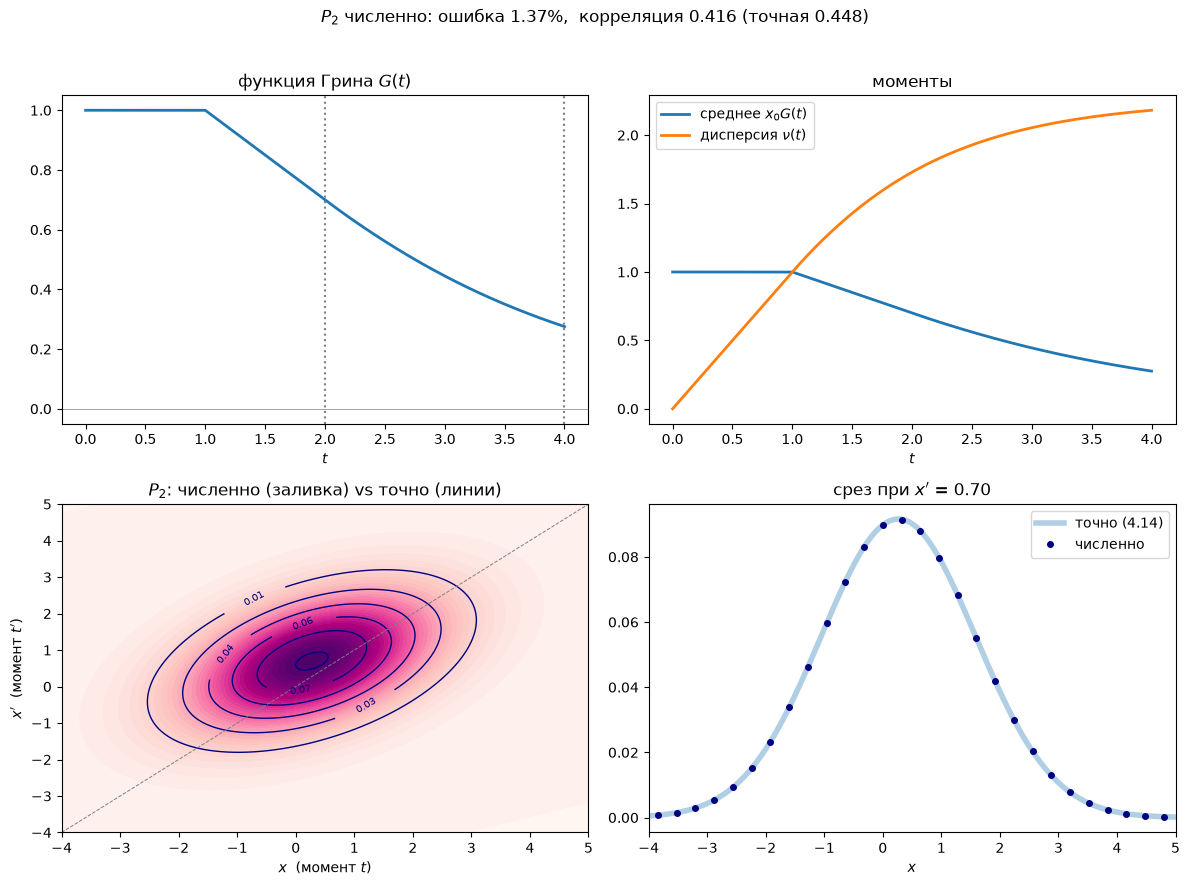

In [5]:
# ============================================================================
# ЯЧЕЙКА 2 — ГРАФИКИ
# ============================================================================
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 2, figsize=(12, 9))

# --- (1) функция Грина: основа всех коэффициентов ---
ax[0,0].plot(np.arange(it+1)*h, G[:it+1], lw=2)
ax[0,0].axvline(tp, color='gray', ls=':'); ax[0,0].axvline(t, color='gray', ls=':')
ax[0,0].axhline(0, color='gray', lw=0.5)
ax[0,0].set_title("функция Грина $G(t)$")
ax[0,0].set_xlabel("$t$")

# --- (2) среднее и дисперсия ---
ax[0,1].plot(np.arange(it+1)*h, x0*G[:it+1], lw=2, label=r"среднее $x_0G(t)$")
ax[0,1].plot(np.arange(it+1)*h, nu[:it+1],   lw=2, label=r"дисперсия $\nu(t)$")
ax[0,1].legend(); ax[0,1].set_title("моменты"); ax[0,1].set_xlabel("$t$")

# --- (3) P2: численно (заливка) vs точно (линии) ---
ax[1,0].contourf(x, x, P2.T, levels=40, cmap='RdPu')
cs = ax[1,0].contour(x, x, P2ex.T, levels=6, colors='navy', linewidths=1)
ax[1,0].clabel(cs, inline=True, fontsize=7, fmt="%.2f")
ax[1,0].plot([-4,5], [-4,5], '--', color='gray', lw=0.7)   # диагональ x=x'
ax[1,0].set_xlim(-4,5); ax[1,0].set_ylim(-4,5)
ax[1,0].set_title("$P_2$: численно (заливка) vs точно (линии)")
ax[1,0].set_xlabel("$x$  (момент $t$)")
ax[1,0].set_ylabel("$x'$  (момент $t'$)")

# --- (4) срез вдоль x при x' = среднее: точки vs линия ---
j = np.argmin(np.abs(x - mtp))
ax[1,1].plot(x, P2ex[:, j], lw=4, alpha=0.35, label="точно (4.14)")
ax[1,1].plot(x[::8], P2[::8, j], 'o', ms=4, color='navy', label="численно")
ax[1,1].set_xlim(-4,5); ax[1,1].legend()
ax[1,1].set_title(f"срез при $x'$ = {mtp:.2f}")
ax[1,1].set_xlabel("$x$")

fig.suptitle(f"$P_2$ численно: ошибка {100*np.max(np.abs(P2-P2ex))/P2ex.max():.2f}%,  "
             f"корреляция {cov/np.sqrt(vx*vxp):.3f} (точная {r:.3f})", fontsize=12)
plt.tight_layout(rect=[0,0,1,0.96])
plt.savefig("/home/claude/result_cells.png", dpi=120)
plt.show()